# Held-Out Control Comparison: Available-Case Analysis

## 1. Summary and scope

Two reviewers completed 177 core-method outputs each. The analysis covers 59 of the 60 registered cases. Both control methods improve human non-target preservation relative to Original FYS; the matched RK2-versus-endpoint human difference remains uncertain. The full pre-registered superiority claim is **not established**.

`synth_0014` completed inference but its output was not saved by the safety filter in every condition. Its automatic metrics and human scores remain missing. Endpoint N=3 has automatic metrics only. This notebook does not replace the original frozen protocol or silently remove its 60th case.

Source prompts and Chinese rubric explanations were added to the single-candidate review page after generation. Reviewer order and IDs were retained. Independence was requested, but cannot be verified from the two CSV files. Uncertainty below is across paired cases, conditional on these two reviewers; it does not estimate variability over a reviewer population.

## 2. Setup and reproducible offline analysis

Use the project `.venv` / `part-level-tdm-localization` kernel. No GPU or model loading is required. GPU-computed LPIPS values are read from archived CSVs. All registered 10,000 bootstrap draws are recalculated locally, retaining paired methods and both ratings within a case. Available strata contain 20 small, 19 medium, and 20 large cases, rather than the registered 20/20/20.

In [1]:
from pathlib import Path
import os, sys, json, subprocess
import numpy as np
import pandas as pd
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'core/scripts/summarize_heldout_available_cases.py').exists())
BASE = ROOT / 'core/results/heldout_control_comparison'
ANALYSIS = BASE / 'final_analysis'
FIGURES = ROOT / 'core/reports/assets/heldout_control_comparison'
FIGURES.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(BASE / '.matplotlib'))
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
subprocess.run([sys.executable, str(ROOT / 'core/scripts/summarize_heldout_available_cases.py'), '--repo-root', str(ROOT)], check=True, capture_output=True, text=True)
METHODS = ['original_fys_tdm', 'endpoint_projection', 'residual_rk2']
ALL = METHODS + ['endpoint_projection_n3']
NAMES = {'original_fys_tdm':'FYS', 'endpoint_projection':'Endpoint N=7', 'residual_rk2':'RK2 N=7', 'endpoint_projection_n3':'Endpoint N=3 (supp.)'}
COLORS = ['#6b7280', '#cf7840', '#168b82', '#9a77ad']
def table(name, **kwargs): return pd.read_csv(ANALYSIS / name, **kwargs)
def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / name, dpi=140, bbox_inches='tight')
    plt.show()
human = table('reviewer_level_scores.csv')
hs = table('human_summary.csv', index_col=0)
auto = pd.read_csv(BASE / 'available_output_evaluation/evaluation_metrics.csv')
av = table('automatic_summary.csv', index_col=0)
hc = table('human_paired_bootstrap.csv')
ac = table('automatic_paired_bootstrap.csv')
manifest = pd.DataFrame(json.loads((ROOT/'core/data/partedit_subset/synth_60_frozen_manifest.json').read_text()))
display(pd.Series(json.loads((ANALYSIS/'coverage.json').read_text())).drop('limitations').to_frame('value'))
display(table('coverage_by_part_size.csv'))
display(table('coverage_by_footprint_change.csv'))

,value
registered_cases,60
available_cases,59
registered_outputs,240
available_outputs,236
core_reviewed_outputs,177
ratings,354
missing_case,synth_0014
bootstrap_iterations,10000
bootstrap_seed,20260903
execution_commit,085e8a3b930bfdf85da4bbbb198e83aede532e37


,part_size,registered,available
0,large,20,20
1,medium,20,19
2,small,20,20


,footprint_change,registered,available
0,comparable,46,45
1,contraction,1,1
2,expansion,13,13


## 3. Methods and evaluation contract

All methods use FLUX.1-dev, seed 0, 15 solver steps and guidance 2.0. The primary control conditions share the same forward-scout part-attention-gated TDM mask and control steps 0–6; steps 7–14 are free target-prompt denoising. Source image-KV injection is disabled in these two conditions. Original FYS retains its native mask and injection schedule, so comparison to FYS is a full-method comparison, not an isolated operation ablation.

**Endpoint projection:**
$$x_{i+1}=M\odot\widetilde{x}_{i+1}+(1-M)\odot s_{i+1}.$$

**Source-referenced residual RK2:** with $d_i=x_i-s_i$, $v_1=v_\theta(x_i,t_i,c_{tgt})$,
$$d_{i+1/2}=d_i+M\odot[\tfrac{h_i}{2}v_1-(s_{i+1/2}-s_i)],\qquad x_{i+1/2}=s_{i+1/2}+d_{i+1/2},$$
$$v_2=v_\theta(x_{i+1/2},t_{i+1/2},c_{tgt}),\qquad d_{i+1}=d_i+M\odot[h_iv_2-(s_{i+1}-s_i)],\quad x_{i+1}=s_{i+1}+d_{i+1}.$$

The supplemental N=3 schedule uses full source image-KV in steps 0–1, projection in steps 2–4 and free denoising thereafter. It is **not** a pure 3-versus-7 prefix-duration ablation.

Saved images are 1024×1024; the frozen evaluator resizes them to 512×512. Strict preservation uses the complement of native GT; buffered preservation uses its dilation by a 32-pixel-radius disk at evaluation resolution. SSIM is the existing global selected-pixel proxy, not sliding-window SSIM. LPIPS uses the existing masked AlexNet implementation. Inside-mask changes measure activity, not semantic success.

## 4. Human scores and paired uncertainty

Joint success is computed for each reviewer before pooling: local edit and preservation both >=1. Strict joint requires both equal 2. The mean of two ratings is used for continuous-score comparisons; the two reviewers are not treated as independent image samples.

,local_edit_success_0_2,non_target_preservation_0_2,overall_prompt_adherence_0_2,visual_quality_0_2,joint_success,strict_joint_success
method,,,,,,
original_fys_tdm,0.9492,0.5932,1.0085,1.8305,0.2881,0.0339
endpoint_projection,1.1017,1.0085,1.2203,1.8475,0.5169,0.1186
residual_rk2,1.1441,1.1102,1.2797,1.8136,0.5169,0.1356


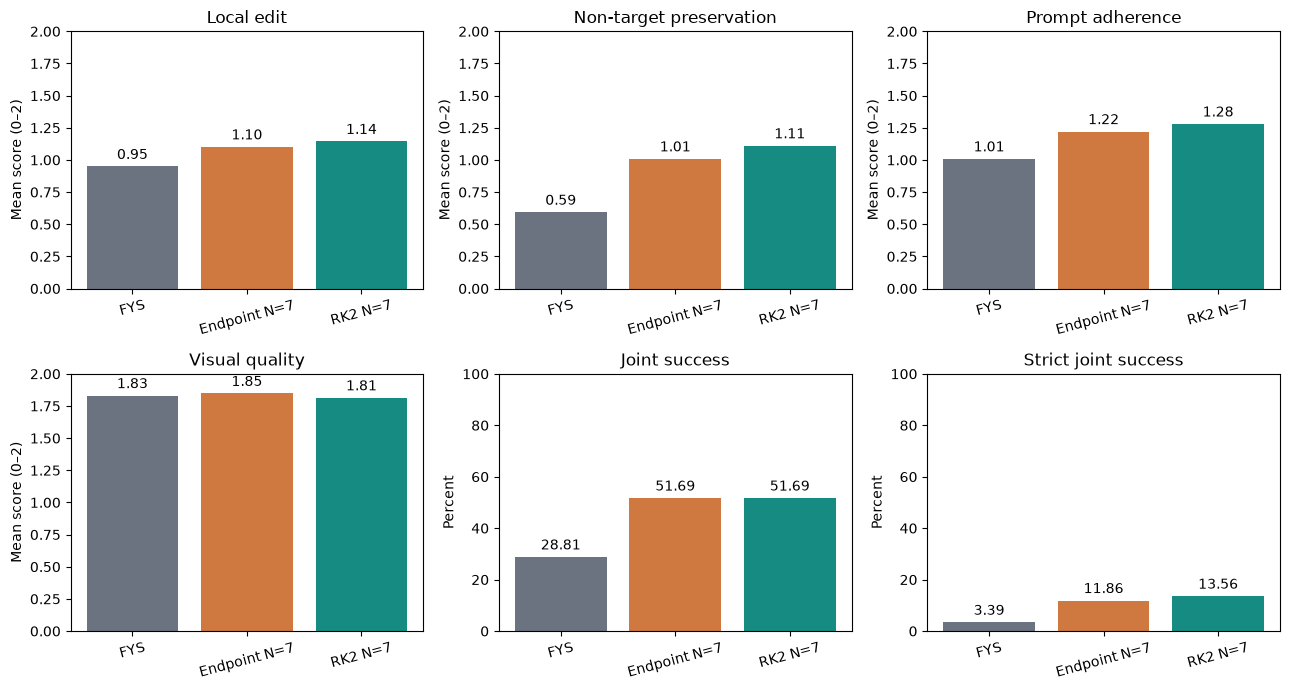

,metric,method_a,method_b,difference,ci_low,ci_high,iterations,paired_cases
0,local_edit_success_0_2,original_fys_tdm,endpoint_projection,-0.1525,-0.3220,0.0169,10000,59
1,non_target_preservation_0_2,original_fys_tdm,endpoint_projection,-0.4153,-0.5932,-0.2458,10000,59
2,overall_prompt_adherence_0_2,original_fys_tdm,endpoint_projection,-0.2119,-0.3729,-0.0508,10000,59
3,visual_quality_0_2,original_fys_tdm,endpoint_projection,-0.0169,-0.1271,0.0763,10000,59
4,joint_success,original_fys_tdm,endpoint_projection,-0.2288,-0.3475,-0.1102,10000,59
5,strict_joint_success,original_fys_tdm,endpoint_projection,-0.0847,-0.1525,-0.0169,10000,59
6,local_edit_success_0_2,original_fys_tdm,residual_rk2,-0.1949,-0.3814,-0.0085,10000,59
7,non_target_preservation_0_2,original_fys_tdm,residual_rk2,-0.5169,-0.6864,-0.3475,10000,59
8,overall_prompt_adherence_0_2,original_fys_tdm,residual_rk2,-0.2712,-0.4576,-0.0847,10000,59
9,visual_quality_0_2,original_fys_tdm,residual_rk2,0.0169,-0.0932,0.1271,10000,59


In [2]:
display(hs.round(4))
fields = ['local_edit_success_0_2','non_target_preservation_0_2','overall_prompt_adherence_0_2','visual_quality_0_2','joint_success','strict_joint_success']
titles = ['Local edit','Non-target preservation','Prompt adherence','Visual quality','Joint success','Strict joint success']
fig, axes = plt.subplots(2,3,figsize=(13,7))
for ax, field, title in zip(axes.ravel(), fields, titles):
    values = hs.loc[METHODS,field].to_numpy()
    if 'joint' in field: values = values * 100
    bars = ax.bar(range(3), values, color=COLORS[:3])
    ax.set_xticks(range(3),[NAMES[m] for m in METHODS],rotation=15)
    ax.set_title(title); ax.set_ylim(0,100 if 'joint' in field else 2)
    ax.bar_label(bars,fmt='%.2f',padding=3)
    ax.set_ylabel('Percent' if 'joint' in field else 'Mean score (0–2)')
save(fig,'human_summary.png')
display(hc.round(4))

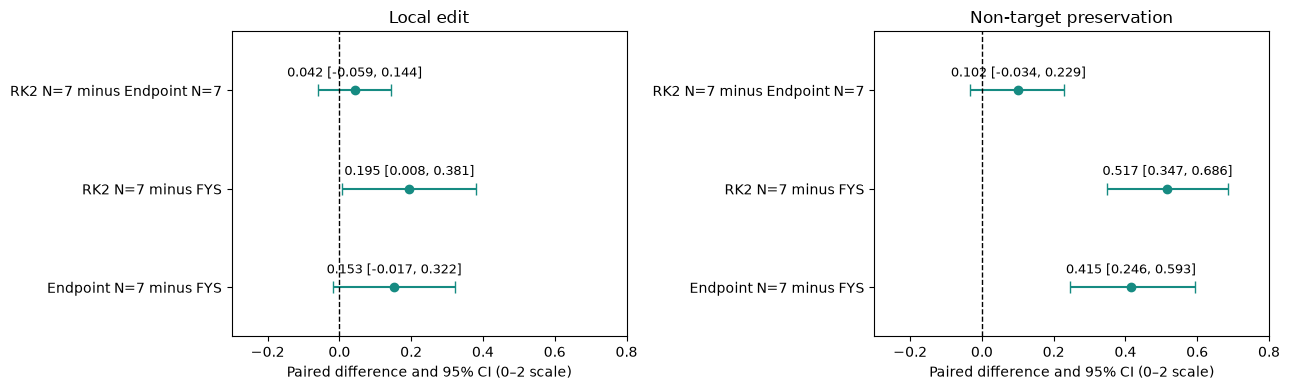

,result
preservation_superiority,False
local_edit_noninferiority,True
stronger_local_edit_baseline,endpoint_projection
joint_utility,True
all_primary_criteria_met,False
scope,Available-case criteria check only; not the co...


In [3]:
def contrast(frame, metric, a, b):
    direct = frame[(frame.metric==metric)&(frame.method_a==a)&(frame.method_b==b)]
    if len(direct): return direct.iloc[0][['difference','ci_low','ci_high']].to_numpy(dtype=float)
    r = frame[(frame.metric==metric)&(frame.method_a==b)&(frame.method_b==a)].iloc[0]
    return np.array([-r.difference,-r.ci_high,-r.ci_low])
pairs=[('endpoint_projection','original_fys_tdm'),('residual_rk2','original_fys_tdm'),('residual_rk2','endpoint_projection')]
fig,axes=plt.subplots(1,2,figsize=(13,4))
for ax,metric,title in zip(axes,fields[:2],titles[:2]):
    for y,(a,b) in enumerate(pairs):
        value,low,high=contrast(hc,metric,a,b)
        ax.errorbar(value,y,xerr=[[value-low],[high-value]],fmt='o',capsize=4,color=COLORS[2])
        ax.annotate(f'{value:.3f} [{low:.3f}, {high:.3f}]',(value,y),xytext=(0,10),textcoords='offset points',ha='center',fontsize=9)
    ax.axvline(0,color='black',linestyle='--',linewidth=1)
    ax.set_yticks(range(3),[f'{NAMES[a]} minus {NAMES[b]}' for a,b in pairs])
    ax.set_ylim(-.5,2.6); ax.set_xlim(-.3,.8); ax.set_title(title); ax.set_xlabel('Paired difference and 95% CI (0–2 scale)')
save(fig,'human_paired_ci.png')
display(pd.Series(json.loads((ANALYSIS/'available_case_criteria.json').read_text())).to_frame('result'))

RK2 and endpoint both have a 51.7% pooled joint rate, compared with 28.8% for FYS. RK2 minus endpoint preservation is 0.102 with CI [-0.034, 0.229], so the required preservation-superiority condition is not met. Local non-inferiority and the joint point-estimate condition pass in this available-case calculation. These checks do not restore the missing case or turn this into the complete frozen primary analysis.

## 5. Automatic preservation and target-region activity

All four conditions are retained here. Supplemental N=3 has no human ratings. Metric-specific percentile CIs are unadjusted for multiple comparisons; interpretation of the central claim is governed by the registered human criteria.

,strict_outside_mask_l1_aux,strict_outside_mask_psnr,strict_outside_mask_global_ssim,strict_outside_mask_lpips
method,,,,
original_fys_tdm,0.03456,23.88879,0.95043,0.12353
endpoint_projection,0.02598,26.70523,0.96980,0.11424
residual_rk2,0.02550,26.90260,0.97138,0.11270
endpoint_projection_n3,0.03045,25.84481,0.96714,0.14371


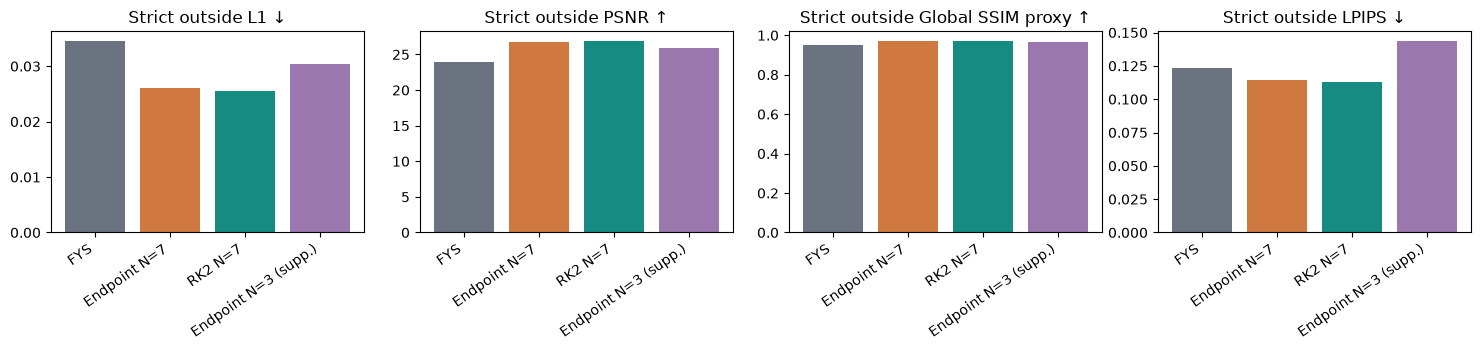

,buffered_outside_mask_l1_aux,buffered_outside_mask_psnr,buffered_outside_mask_global_ssim,buffered_outside_mask_lpips
method,,,,
original_fys_tdm,0.03275,24.51299,0.95458,0.10676
endpoint_projection,0.02395,27.85796,0.97546,0.09824
residual_rk2,0.02347,28.09805,0.97719,0.09665
endpoint_projection_n3,0.02896,26.49815,0.97040,0.12735


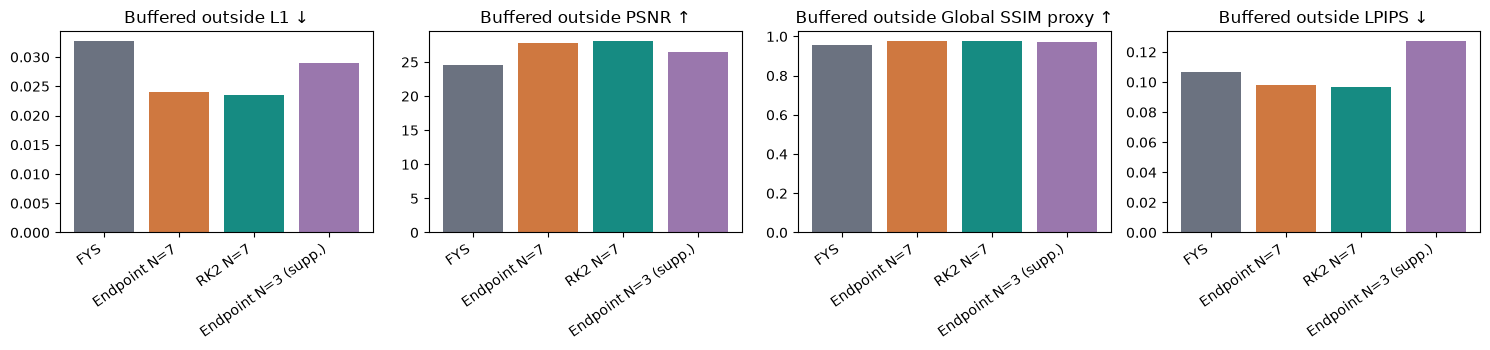

,metric,method_a,method_b,difference,ci_low,ci_high,iterations,paired_cases
16,strict_outside_mask_lpips,original_fys_tdm,endpoint_projection,0.00930,-0.00053,0.01894,10000,59
17,buffered_outside_mask_lpips,original_fys_tdm,endpoint_projection,0.00852,-0.00128,0.01801,10000,59
34,strict_outside_mask_lpips,original_fys_tdm,residual_rk2,0.01083,0.00096,0.02063,10000,59
35,buffered_outside_mask_lpips,original_fys_tdm,residual_rk2,0.01011,0.00031,0.01967,10000,59
52,strict_outside_mask_lpips,original_fys_tdm,endpoint_projection_n3,-0.02018,-0.03037,-0.01045,10000,59
53,buffered_outside_mask_lpips,original_fys_tdm,endpoint_projection_n3,-0.02059,-0.03052,-0.01099,10000,59
70,strict_outside_mask_lpips,endpoint_projection,residual_rk2,0.00154,0.00045,0.00272,10000,59
71,buffered_outside_mask_lpips,endpoint_projection,residual_rk2,0.00159,0.00050,0.00290,10000,59
88,strict_outside_mask_lpips,endpoint_projection,endpoint_projection_n3,-0.02947,-0.03463,-0.02415,10000,59
89,buffered_outside_mask_lpips,endpoint_projection,endpoint_projection_n3,-0.02911,-0.03394,-0.02428,10000,59


,strict_inside_mask_l1_aux,strict_inside_mask_psnr,strict_inside_mask_global_ssim,buffered_inside_mask_l1_aux,buffered_inside_mask_psnr,buffered_inside_mask_global_ssim
method,,,,,,
original_fys_tdm,0.07421,19.50704,0.81784,0.06233,19.83675,0.89036
endpoint_projection,0.08234,18.87709,0.80299,0.06190,20.19870,0.89176
residual_rk2,0.07968,19.17887,0.81194,0.06055,20.39110,0.89588
endpoint_projection_n3,0.06851,20.26172,0.84621,0.05533,21.07211,0.91463


In [4]:
for region in ['strict','buffered']:
    columns=[f'{region}_outside_mask_{suffix}' for suffix in ['l1_aux','psnr','global_ssim','lpips']]
    display(av.loc[ALL,columns].round(5))
    fig,axes=plt.subplots(1,4,figsize=(15,3.6))
    for ax,col,title in zip(axes,columns,['L1 ↓','PSNR ↑','Global SSIM proxy ↑','LPIPS ↓']):
        ax.bar(range(4),av.loc[ALL,col],color=COLORS)
        ax.set_xticks(range(4),[NAMES[m] for m in ALL],rotation=35,ha='right')
        ax.set_title(f'{region.capitalize()} outside {title}'); ax.set_ylim(bottom=0)
    save(fig,f'automatic_{region}.png')
display(ac[ac.metric.str.contains('lpips')].round(5))
activity=[c for c in av if 'inside_mask' in c and not c.endswith('mse')]
display(av[activity].round(5))

RK2's strict LPIPS is 0.11270 versus endpoint's 0.11424. The paired RK2-minus-endpoint interval is [-0.00272, -0.00045], a small consistent numerical improvement. It does not substitute for the uncertain human preservation difference. N=3 has worse LPIPS than FYS despite better L1/PSNR, illustrating that preservation metrics are not interchangeable.

## 6. Reviewer agreement and consensus sensitivity

Report both weighted kappa and raw agreement. High exact agreement can coexist with low kappa when score distributions are heavily concentrated. Do not resolve disagreements by choosing the higher score or adjudicating after seeing method identity.

,criterion,weighted_kappa,exact_agreement
0,local_edit_success_0_2,0.7025,0.7458
1,non_target_preservation_0_2,0.4390,0.5989
2,overall_prompt_adherence_0_2,0.5564,0.6723
3,visual_quality_0_2,0.0796,0.7458


,reviewer_id,method,local_edit_success_0_2,non_target_preservation_0_2,overall_prompt_adherence_0_2,visual_quality_0_2,joint_success,strict_joint_success
0,reviewer_1,endpoint_projection,1.0847,1.0508,1.1525,1.6949,0.5424,0.1356
1,reviewer_1,original_fys_tdm,0.9492,0.5932,0.9831,1.7458,0.3051,0.0339
2,reviewer_1,residual_rk2,1.1356,1.0678,1.2373,1.6780,0.4915,0.1525
3,reviewer_2,endpoint_projection,1.1186,0.9661,1.2881,2.0000,0.4915,0.1017
4,reviewer_2,original_fys_tdm,0.9492,0.5932,1.0339,1.9153,0.2712,0.0339
5,reviewer_2,residual_rk2,1.1525,1.1525,1.3220,1.9492,0.5424,0.1186


,method,joint_success,strict_joint_success
0,endpoint_projection,0.3898,0.0508
1,original_fys_tdm,0.1525,0.0169
2,residual_rk2,0.4068,0.0678


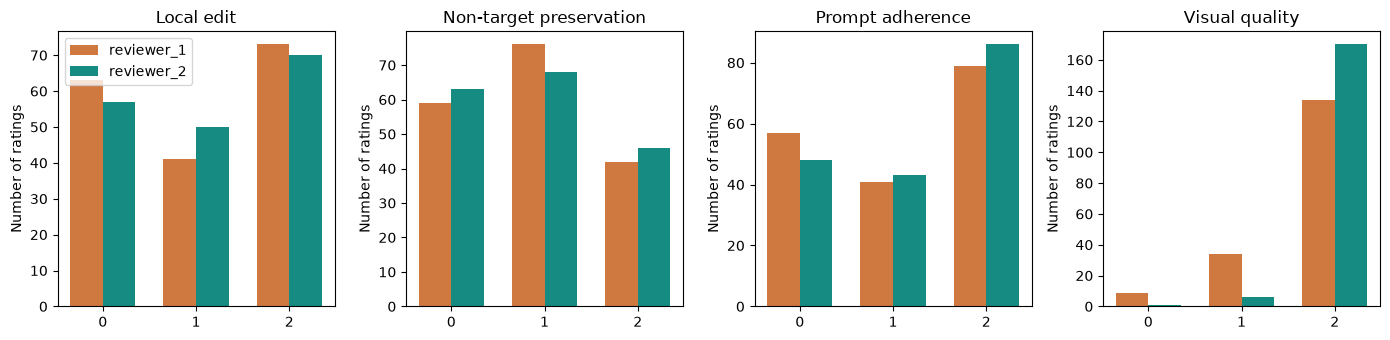

In [5]:
display(table('interrater_agreement.csv').round(4))
display(table('per_reviewer_summary.csv').round(4))
display(table('consensus_joint_summary.csv').round(4))
dist=table('score_distributions.csv')
fig,axes=plt.subplots(1,4,figsize=(14,3.5))
for ax,metric,title in zip(axes,fields[:4],titles[:4]):
    for i,r in enumerate(['reviewer_1','reviewer_2']):
        counts=dist[(dist.metric==metric)&(dist.reviewer_id==r)].set_index('score').reindex([0,1,2])['count']
        ax.bar(np.arange(3)+(i-.5)*.35,counts,width=.35,label=r,color=COLORS[i+1])
    ax.set_xticks([0,1,2]);ax.set_title(title);ax.set_ylabel('Number of ratings')
axes[0].legend()
save(fig,'reviewer_distributions.png')

Visual-quality kappa is only 0.080. Reviewer 2 assigned 2 to 170/177 images, compared with 134/177 for reviewer 1. This ceiling effect and reviewer calibration difference limit interpretation of the small quality differences.

## 7. Subgroups and all-case human assessment

Subgroups are exploratory. There is only one contraction case in the dataset; it cannot support a general contraction-edit claim. Heatmaps use the mean of the two reviewers, including half-point values.

,part_size,method,local_edit_success_0_2,non_target_preservation_0_2,overall_prompt_adherence_0_2,visual_quality_0_2,joint_success,strict_joint_success
0,large,endpoint_projection,1.350,0.950,1.350,1.875,0.525,0.100
1,large,original_fys_tdm,0.925,0.625,1.075,1.900,0.350,0.075
2,large,residual_rk2,1.325,1.025,1.475,1.875,0.475,0.200
3,medium,endpoint_projection,1.053,1.026,1.132,1.921,0.447,0.211
4,medium,original_fys_tdm,1.053,0.500,1.000,1.737,0.263,0.026
5,medium,residual_rk2,1.079,1.184,1.211,1.868,0.526,0.158
6,small,endpoint_projection,0.900,1.050,1.175,1.750,0.575,0.050
7,small,original_fys_tdm,0.875,0.650,0.950,1.850,0.250,0.000
8,small,residual_rk2,1.025,1.125,1.150,1.700,0.550,0.050


,footprint_change,method,local_edit_success_0_2,non_target_preservation_0_2,overall_prompt_adherence_0_2,visual_quality_0_2,joint_success,strict_joint_success
0,comparable,endpoint_projection,1.222,0.911,1.300,1.878,0.533,0.122
1,comparable,original_fys_tdm,1.022,0.522,1.078,1.833,0.322,0.022
2,comparable,residual_rk2,1.244,0.989,1.389,1.867,0.533,0.144
3,contraction,endpoint_projection,0.000,1.000,0.500,2.000,0.000,0.000
4,contraction,original_fys_tdm,0.000,1.000,0.500,2.000,0.000,0.000
5,contraction,residual_rk2,0.500,1.500,1.500,1.500,0.500,0.000
6,expansion,endpoint_projection,0.769,1.346,1.000,1.731,0.500,0.115
7,expansion,original_fys_tdm,0.769,0.808,0.808,1.808,0.192,0.077
8,expansion,residual_rk2,0.846,1.500,0.885,1.654,0.462,0.115


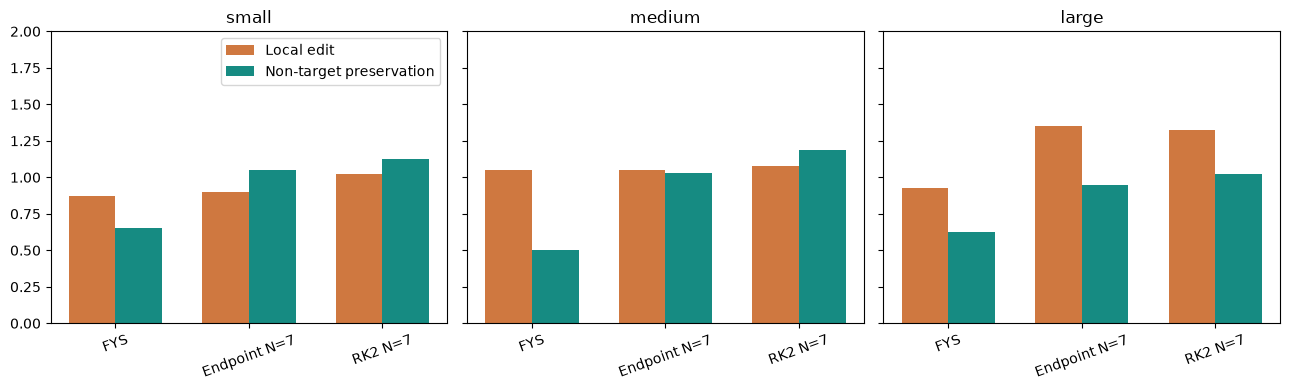

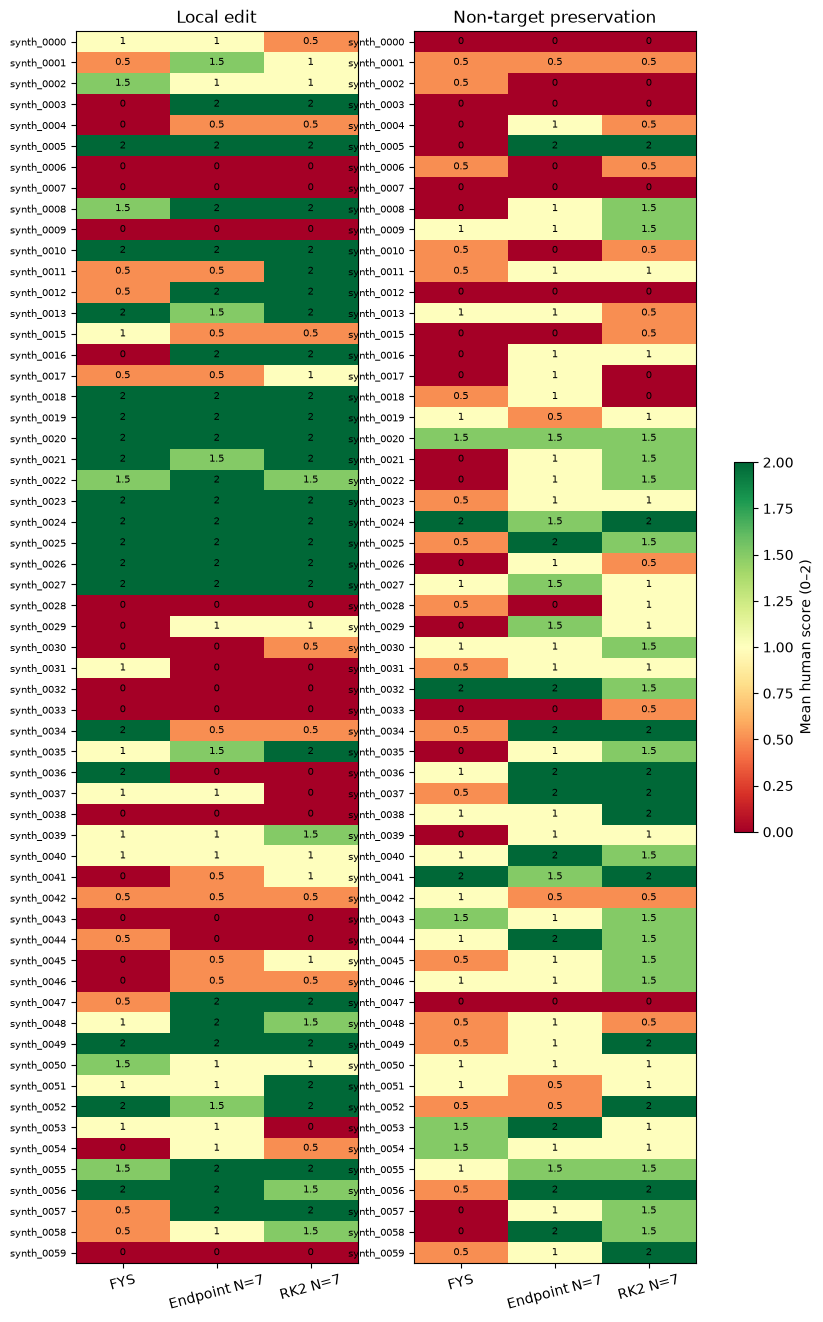

In [6]:
display(table('human_by_part_size.csv').round(3))
display(table('human_by_footprint_change.csv').round(3))
fig,axes=plt.subplots(1,3,figsize=(13,4),sharey=True)
for ax,size in zip(axes,['small','medium','large']):
    group=human[human.part_size==size].groupby('method')[fields[:2]].mean().reindex(METHODS)
    for i,field in enumerate(fields[:2]):
        ax.bar(np.arange(3)+(i-.5)*.35,group[field],width=.35,label=titles[i],color=COLORS[i+1])
    ax.set_xticks(range(3),[NAMES[m] for m in METHODS],rotation=20); ax.set_ylim(0,2);ax.set_title(size)
axes[0].legend();save(fig,'human_by_size.png')
fig,axes=plt.subplots(1,2,figsize=(10,16))
case_order=sorted(human.case_uid.unique())
for ax,field,title in zip(axes,fields[:2],titles[:2]):
    values=human.pivot_table(index='case_uid',columns='method',values=field).reindex(index=case_order,columns=METHODS)
    im=ax.imshow(values,vmin=0,vmax=2,cmap='RdYlGn',aspect='auto')
    ax.set_xticks(range(3),[NAMES[m] for m in METHODS],rotation=15);ax.set_yticks(range(len(values)),values.index,fontsize=7);ax.set_title(title)
    for y,row in enumerate(values.to_numpy()):
        for x,v in enumerate(row): ax.text(x,y,f'{v:g}',ha='center',va='center',fontsize=7)
fig.colorbar(im,ax=axes.ravel().tolist(),shrink=.3,label='Mean human score (0–2)')
fig.savefig(FIGURES/'human_case_heatmap.png',dpi=130,bbox_inches='tight');plt.show()

## 8. Shared-mask localization

Each shared scout mask is counted once per case, not once per method. The 59 available masks have mean IoU 0.336, AP 0.522 and area/GT ratio 1.941. These are localization measurements, not proof of edit success. The missing case is outside this outcome-linked table even if intermediate scout maps exist.

,Unnamed: 0,mask_iou,mask_ap,mask_area_over_gt
0,mean,0.336178,0.522205,1.940901
1,median,0.333333,0.491821,1.687747


mask_iou        mask_ap        mask_area_over_gt       
              mean median    mean median              mean median
part_size                                                        
large        0.363  0.372   0.528  0.488             1.471  1.417
medium       0.338  0.267   0.493  0.411             1.648  1.556
small        0.307  0.343   0.545  0.540             2.689  2.074

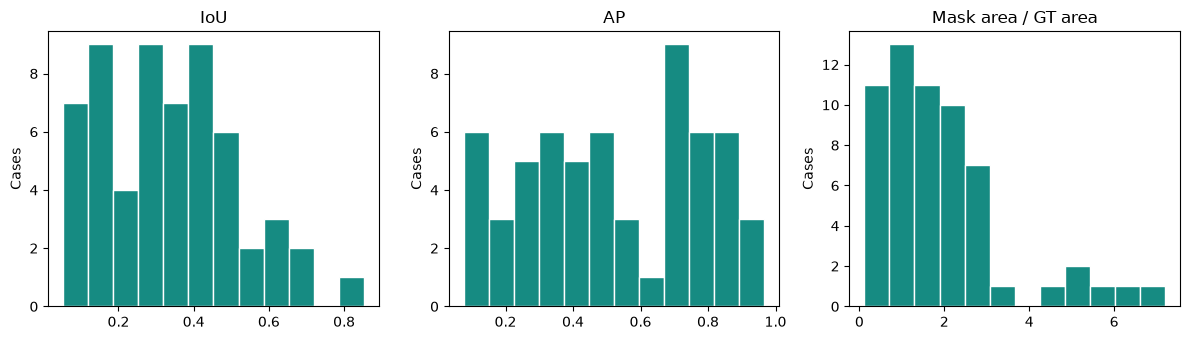

In [7]:
loc=table('localization_per_case.csv')
display(table('localization_summary.csv'))
display(loc.groupby('part_size')[['mask_iou','mask_ap','mask_area_over_gt']].agg(['mean','median']).round(3))
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for ax,col,title in zip(axes,['mask_iou','mask_ap','mask_area_over_gt'],['IoU','AP','Mask area / GT area']):
    ax.hist(loc[col],bins=12,color=COLORS[2],edgecolor='white');ax.set_title(title);ax.set_ylabel('Cases')
save(fig,'localization.png')

## 9. Qualitative examples and complete gallery

Illustrations are selected after scoring using a stated rule: lowest-index RK2 cases in the categories strict consensus success, local-edit failure, and mixed outcome (up to two per category). They are descriptive examples, not an independent test. A complete 60-case gallery is also exported in dataset order; the missing case is visibly marked. Source, GT overlay, and each generated output are kept separate.

Each row shows source, evaluation GT (red), actual FYS TDM mask (blue), actual shared gate mask (blue), and the three outputs. Saved binary masks are resized with nearest-neighbor interpolation without smoothing or re-thresholding; 1 denotes edit support. Endpoint and RK2 mask paths are checked against the shared scout artifact. All 60 individual figures and an indexed viewer document are exported alongside the three contact sheets.

,case_uid,selection
0,synth_0005,strict consensus
1,synth_0024,strict consensus
2,synth_0006,local failure
3,synth_0007,local failure
4,synth_0000,mixed / other
5,synth_0001,mixed / other


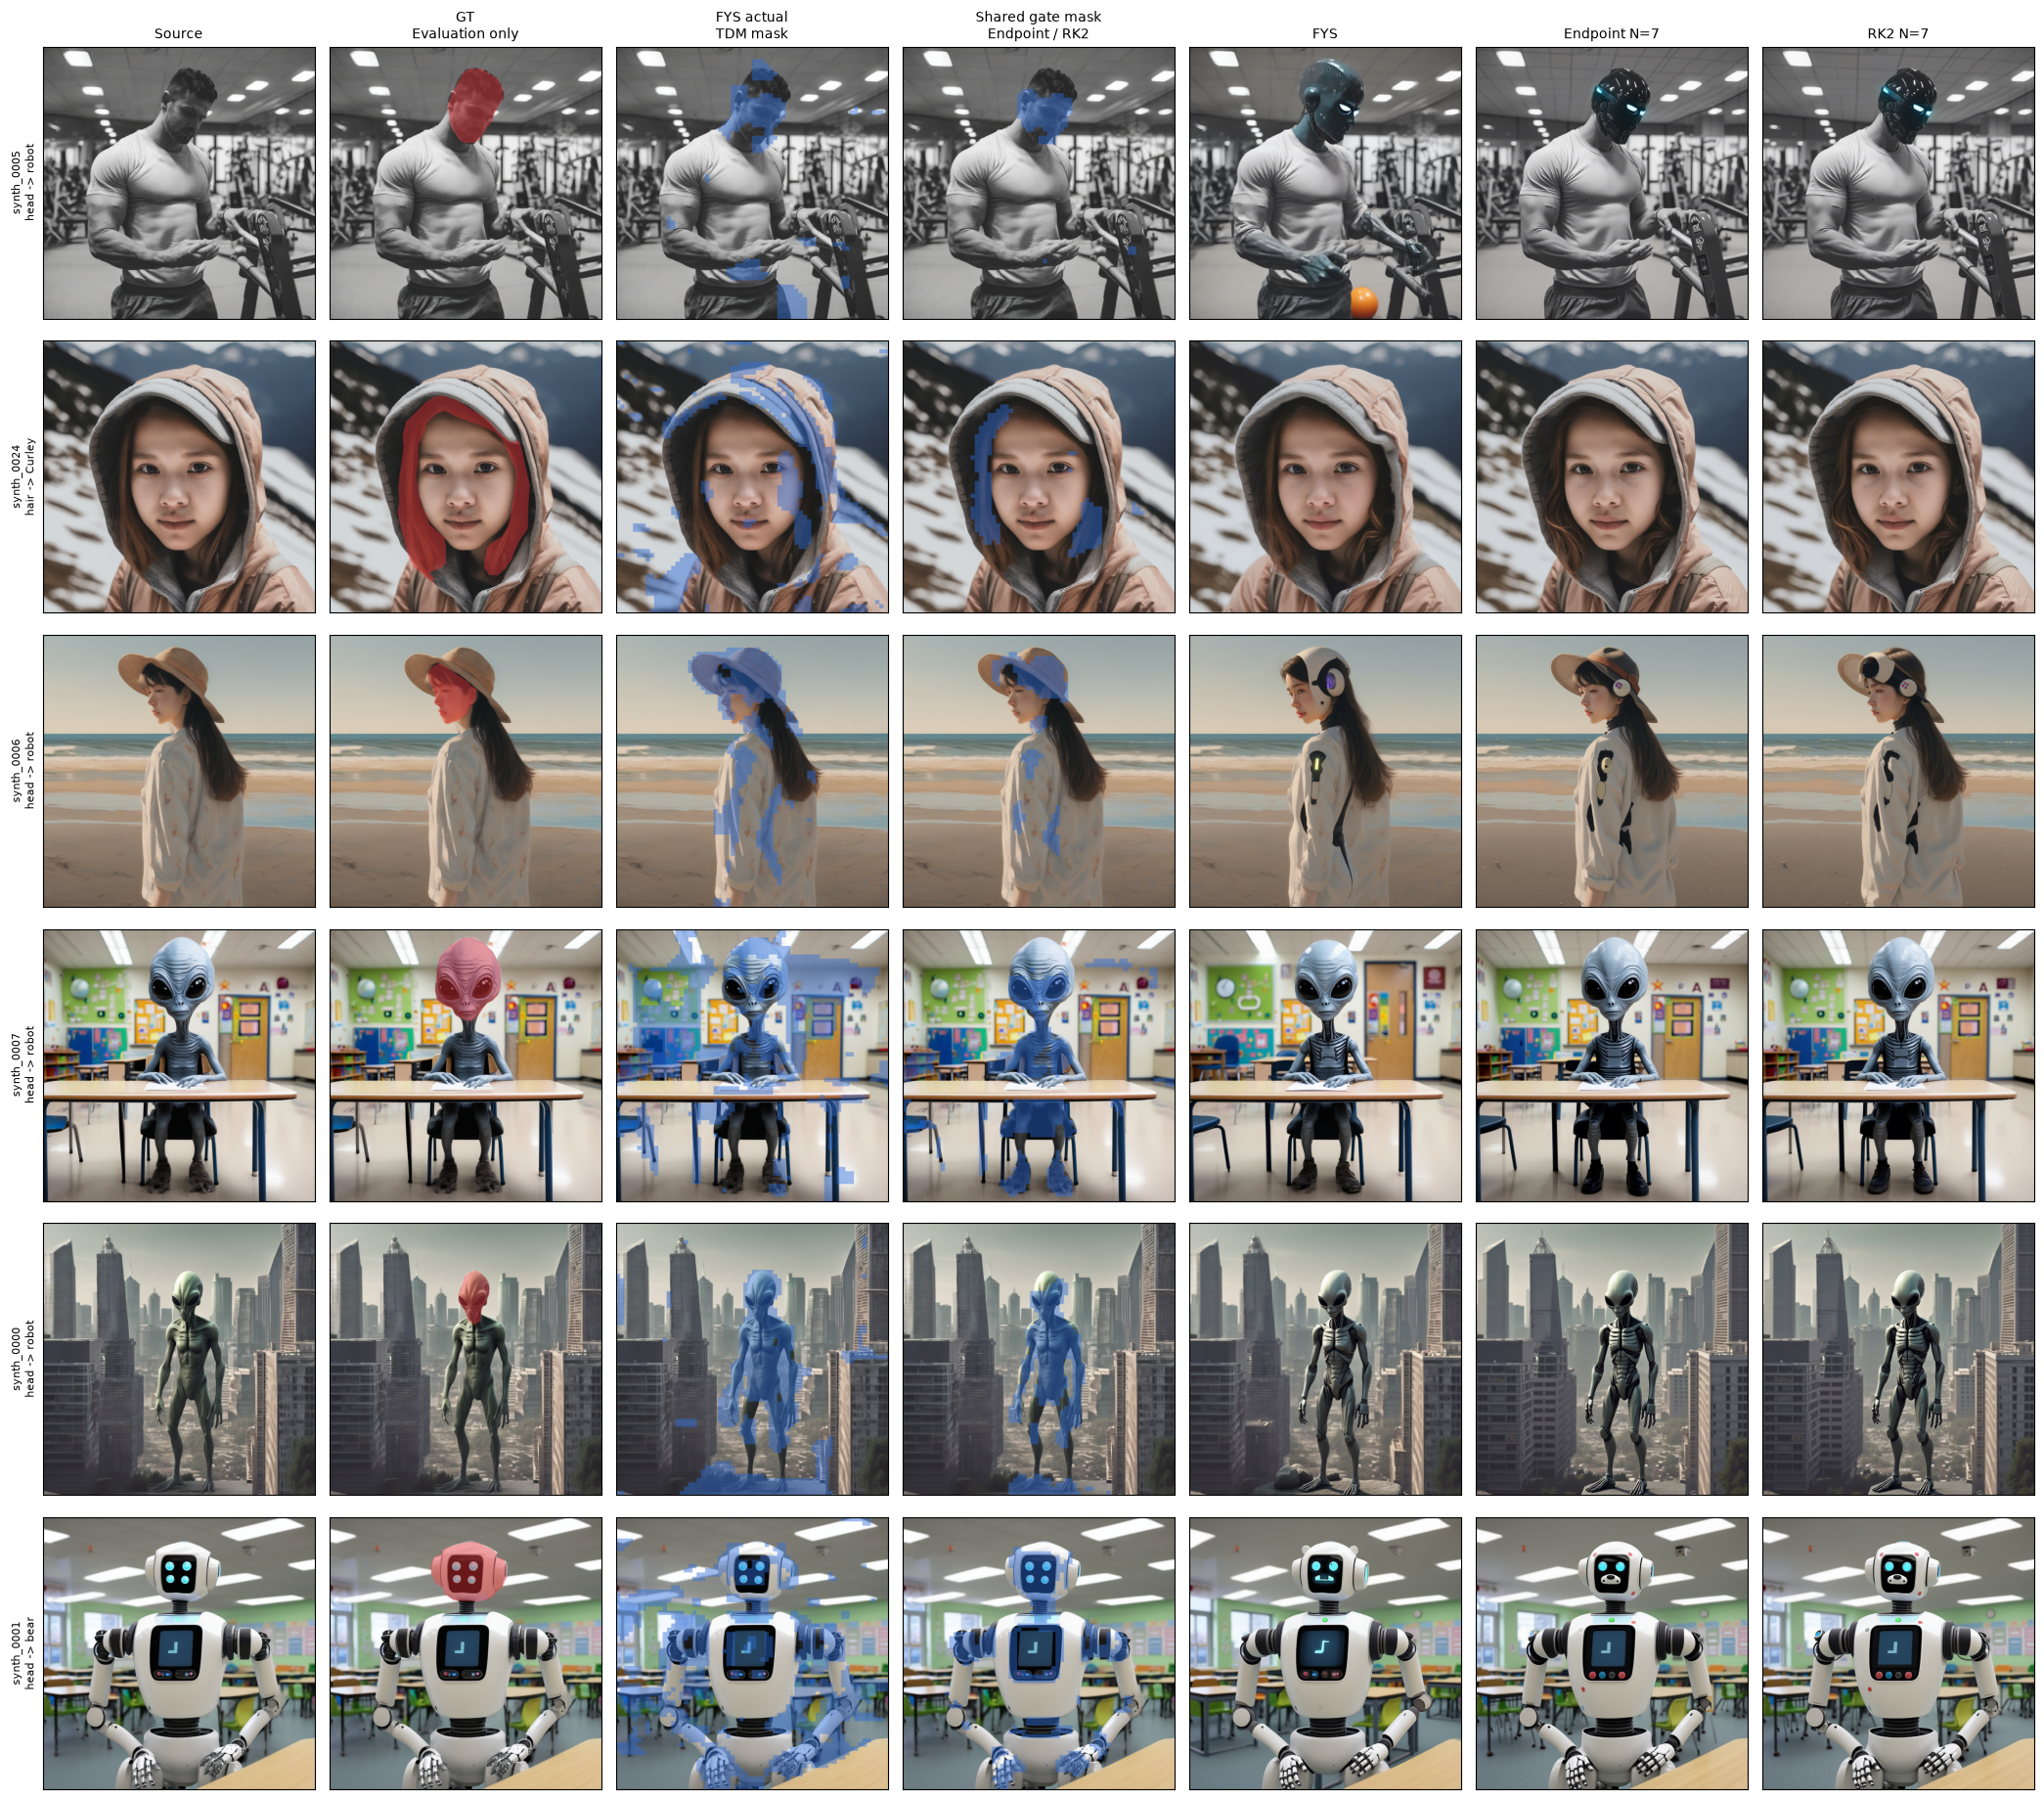

Exported 60 individual figures, three contact sheets, and all_cases.md under /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/reports/assets/heldout_control_comparison


In [8]:
case_scores=human.groupby(['case_uid','method'])[fields[:2]].mean()
rk=case_scores.xs('residual_rk2',level='method').sort_index()
success=rk[(rk[fields[0]]==2)&(rk[fields[1]]==2)].index.tolist()[:2]
failure=rk[rk[fields[0]]==0].index.tolist()[:2]
mixed=rk[~rk.index.isin(success+failure)].index.tolist()[:2]
selected=success+failure+mixed
selection=pd.DataFrame({'case_uid':selected,'selection':['strict consensus']*len(success)+['local failure']*len(failure)+['mixed / other']*len(mixed)})
selection.to_csv(ANALYSIS/'qualitative_selection.csv',index=False)
display(selection)
records=manifest.set_index('case_uid')

def actual_masks(case):
    fys_path=BASE/'original_fys_tdm'/case/'seed_000/tdm/selected_binary_tdm_mask.npy'
    shared_path=BASE/'attention_mask_scout'/case/'seed_000/tdm/hybrid_binary_tdm_attention.npy'
    for method in ['endpoint_projection','residual_rk2']:
        config=json.loads((BASE/method/case/'seed_000/run_config.json').read_text())
        assert config['control_mask_path'].endswith(str(shared_path.relative_to(BASE)))
    masks=[]
    for path in [fys_path,shared_path]:
        value=np.load(path).squeeze()
        assert value.ndim==2 and np.isfinite(value).all(), path
        assert set(np.unique(value)).issubset({0,1}), path
        masks.append(value.astype(bool))
    return masks

def overlay_mask(source,mask,color):
    mask=np.asarray(Image.fromarray(mask.astype(np.uint8)*255).resize(source.size,Image.Resampling.NEAREST))>0
    out=np.asarray(source).astype(float).copy()
    out[mask]=.55*out[mask]+.45*np.asarray(color)
    return out.astype(np.uint8)

def panel(case_ids,filename,show=True):
    fig,axes=plt.subplots(len(case_ids),7,figsize=(21,len(case_ids)*3.1),squeeze=False)
    titles=['Source','GT\nEvaluation only','FYS actual\nTDM mask','Shared gate mask\nEndpoint / RK2',*[NAMES[m] for m in METHODS]]
    for i,case in enumerate(case_ids):
        r=records.loc[case]
        source=Image.open(ROOT/r.source_image).convert('RGB')
        gt=np.asarray(Image.open(ROOT/r.gt_mask).convert('L'))>0
        fys,shared=actual_masks(case)
        images=[source,overlay_mask(source,gt,[230,50,55]),overlay_mask(source,fys,[45,110,220]),overlay_mask(source,shared,[45,110,220])]
        for method in METHODS:
            path=BASE/method/case/'seed_000/img_0.jpg'
            images.append(Image.open(path).convert('RGB') if path.exists() else None)
        for j,img in enumerate(images):
            ax=axes[i,j];ax.set_xticks([]);ax.set_yticks([])
            if img is None:
                ax.text(.5,.5,'Output not saved\nSafety filter',ha='center',va='center',transform=ax.transAxes)
            else:ax.imshow(img)
            if i==0:ax.set_title(titles[j],fontsize=10)
        axes[i,0].set_ylabel(f'{case}\n{r.part} -> {r.edit}',fontsize=8)
    fig.tight_layout();fig.savefig(FIGURES/filename,dpi=120,bbox_inches='tight')
    if show:plt.show()
    plt.close(fig)

panel(selected,'representative_cases.png')
all_cases=manifest.sort_values('dataset_index').case_uid.tolist()
assert len(all_cases)==60 and len(set(all_cases))==60
for i in range(3):panel(all_cases[i*20:(i+1)*20],f'all_cases_{i+1}.jpg',show=False)
(FIGURES/'cases').mkdir(exist_ok=True)
for case in all_cases:panel([case],f'cases/{case}.jpg',show=False)
index=['# All 60 Cases','', 'Red: evaluation GT. Blue: actual binary edit support. Masks are overlaid on the source, not on generated outputs.', '', 'Columns: source, GT, FYS TDM mask, shared gate mask, FYS output, Endpoint N=7 output, RK2 N=7 output.', '', 'synth_0014 retains its source and masks; final outputs were not saved by the safety filter.', '']
for case in all_cases:
    r=records.loc[case]
    index += [f'## {case}: {r.part} -> {r.edit}', '', f'Target: {r.target_prompt}', '', f'![{case}](cases/{case}.jpg)', '']
(FIGURES/'all_cases.md').write_text('\n'.join(index))
print('Exported 60 individual figures, three contact sheets, and all_cases.md under',FIGURES)


## 10. Conclusions and remaining boundaries

- The matched comparison does not establish RK2 superiority over endpoint projection under the registered human preservation requirement.
- Both control methods improve preservation relative to native FYS; that comparison also changes mask and schedule, so it does not isolate control alone.
- Small numerical LPIPS advantages for RK2 coexist with uncertain human differences. Better preservation does not imply every requested part edit succeeds.
- Source/candidate hashes were checked for all 354 ratings. No PartEdit reference was shown as the source or candidate.
- The full 60-case inference population, missing-output handling and reviewer-display deviations must remain explicit. No silent zero scores or selective reruns were introduced.
- Endpoint N=3 human scoring is deferred. A future RK2 N=15 run would be a separate, post-result exploratory study, not a replacement for N=7.

The standalone report is `core/reports/heldout_control_comparison_results.md`. Generated tables and audit hashes are under `core/results/heldout_control_comparison/final_analysis/`.